<a href="https://colab.research.google.com/github/gabrielcggs/CP02-SERS-MACHINE-LEARNING/blob/main/CP2_SERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PREPARAÇÃO AMBIENTE

In [62]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learnng
# Algoritmos do sklearn para Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Algoritmos do sklearn para Regressão
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Separação os dados de treino e teste
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test

# Métrica de avaliação para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

#Métricas de avaliação import
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.metrics import classification_report # resumo de métricas

## Tarefa 1 — Classificação (ANEEL)

In [63]:
dados = pd.read_csv("/content/aneel_classificacao_orange.csv")

In [64]:
dados.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


##ANÁLISE

In [65]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [66]:
# Somente estatísticas de atributos categóricos
dados.describe(include = 'object')

,fonte
count,3876
unique,3
top,Hidráulica
freq,1476


In [67]:
# somente estatísticas de atributos númericos
dados.describe()

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


In [68]:
# Checando a quantidade de classes da coluna alvo (fonte)
dados['fonte'].unique()

array(['Solar', 'Eólica', 'Hidráulica'], dtype=object)

In [69]:
# Checando a quantidade de valores de cada classe da coluna alvo (stabf)
dados['fonte'].value_counts()


,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


## Separação de dados:
 Entrada (features) -----> X

 Saída(target) -----> y


In [70]:
#Features
X = dados.drop(['fonte'], axis = 1)
X.head()

,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000


In [71]:
# Variável alvo(target)
y = dados['fonte']
y.head()

,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


## Separação de dados de treino e teste

In [72]:
X_train, X_teste, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 17)

In [73]:
X.shape

(3876, 3)

In [74]:
X_train.shape # 80% dos dados para treino

(3100, 3)

In [75]:
X_teste.shape # 20% dos dados para teste

(776, 3)

##Treinamento de modelos usando 3 algoritmos para classificação diferentes

In [76]:
# Instanciando o modelo
modelo_LR = LogisticRegression()
# Treinando o modelo
modelo_LR.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [77]:
# Instanciando o modelo
modelo_RFC = RandomForestClassifier()
# Treinando o modelo
modelo_RFC.fit(X_train, y_train)

RandomForestClassifier()

In [78]:
# Instanciando o modelo
modelo_KNC = KNeighborsClassifier()
# Treinando o modelo
modelo_KNC.fit(X_train, y_train)

KNeighborsClassifier()

GERANDO PREVISÕES

In [79]:
y_predictLR = modelo_LR.predict(X_teste)
y_predictLR

array(['Solar', 'Solar', 'Hidráulica', 'Hidráulica', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Eólica',
       'Eólica', 'Hidráulica', 'Eólica', 'Eólica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Solar', 'Hidráulica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Hidráulica', 'Solar', 'Solar', 'Solar', 'Solar',
       'Eólica', 'Eólica', 'Eólica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Eólica',
       'Solar', 'Solar', 'Hidráulica', 'Eólica', 'Solar', 'Eólica',
       'Solar', 'Solar', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Solar', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Eólica', 'Eólica', 'Solar', 'Hidráulica', 'Solar', 'Solar',
       'Solar', 'Hidráulica', 'Hidráulica', 'Solar', 'Solar', 'Eólica',
       'Hidráulica', 'So

In [80]:
y_predictRFC = modelo_RFC.predict(X_teste)
y_predictRFC

array(['Solar', 'Solar', 'Hidráulica', 'Solar', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Eólica', 'Hidráulica', 'Eólica', 'Eólica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Hidráulica', 'Solar', 'Solar', 'Solar', 'Solar',
       'Solar', 'Eólica', 'Eólica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Solar', 'Solar', 'Hidráulica', 'Eólica', 'Solar',
       'Solar', 'Hidráulica', 'Eólica', 'Solar', 'Eólica', 'Eólica',
       'Eólica', 'Hidráulica', 'Eólica', 'Eólica', 'Hidráulica', 'Eólica',
       'Solar', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Solar', 'Eólica', 'Hidráulica',
       'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica', 'Hidráulica',
       'Eólica', 'Eólica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Solar',
       'Hid

In [81]:
y_predictKNC = modelo_KNC.predict(X_teste)
y_predictKNC

array(['Solar', 'Solar', 'Hidráulica', 'Solar', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Hidráulica', 'Eólica', 'Eólica', 'Solar',
       'Hidráulica', 'Solar', 'Solar', 'Solar', 'Eólica', 'Solar',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Solar', 'Solar', 'Hidráulica', 'Solar', 'Solar',
       'Solar', 'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Solar', 'Eólica', 'Hidráulica',
       'Eólica', 'Solar', 'Solar', 'Hidráulica', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Eólica', 'Eólica',
       'Eólica', 'Eólica', 'Solar', 'Hidráulica', 'Hidráulica', 'Eólica',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar', 'Eólica',
       'Hidráulica', 'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Solar', '

## Avaliação do modelo

In [82]:
# Acurácia
acuraciaLR = 100 * accuracy_score(y_test, y_predictLR)
print(f'A acurácia do modelo baseado em Regressão Logística é: {acuraciaLR:.2f}%')

acuraciaRFC = 100 * accuracy_score(y_test, y_predictRFC)
print(f'A acurácia do modelo baseado em RandomForestClassifier é: {acuraciaRFC:.2f}%')

acuraciaKNC = 100 * accuracy_score(y_test, y_predictKNC)
print(f'A acurácia do modelo baseado em KNeighborsClassifier é: {acuraciaKNC:.2f}%')

A acurácia do modelo baseado em Regressão Logística é: 71.13%
A acurácia do modelo baseado em RandomForestClassifier é: 97.81%
A acurácia do modelo baseado em KNeighborsClassifier é: 85.57%


In [83]:
# Recall
recallLR = recall_score(y_test, y_predictLR, average='weighted')
print(f'O recall do modelo baseado em Regressão Logística é: {recallLR:.2f}%')

recallRFC =  recall_score(y_test, y_predictRFC, average='weighted')
print(f'O recall do modelo baseado em RandomForestClassifier é: {recallRFC:.2f}%')

recallKNC = recall_score(y_test, y_predictKNC, average='weighted')
print(f'O recall do modelo baseado em KNeighborsClassifier é: {recallKNC:.2f}%')

O recall do modelo baseado em Regressão Logística é: 0.71%
O recall do modelo baseado em RandomForestClassifier é: 0.98%
O recall do modelo baseado em KNeighborsClassifier é: 0.86%


In [84]:
# F1-Score
f1LR = f1_score(y_test, y_predictLR, average='weighted')
print(f'O F1-Score do modelo baseado em Regressão Logística é: {f1LR:.2f}%')

f1RFC =  f1_score(y_test, y_predictRFC, average='weighted')
print(f'O F1-Score do modelo baseado em RandomForestClassifier é: {f1RFC:.2f}%')

f1KNC = f1_score(y_test, y_predictKNC, average='weighted')
print(f'O F1-Score do modelo baseado em KNeighborsClassifier é: {f1KNC:.2f}%')

O F1-Score do modelo baseado em Regressão Logística é: 0.71%
O F1-Score do modelo baseado em RandomForestClassifier é: 0.98%
O F1-Score do modelo baseado em KNeighborsClassifier é: 0.86%


In [85]:
# Precisao
precisaoLR = precision_score(y_test, y_predictLR, average='weighted')
print(f'A precisão do modelo baseado em Regressão Logística é: {precisaoLR:.2f}%')

precisaoRFC = precision_score(y_test, y_predictRFC, average='weighted')
print(f'A precisão do modelo baseado em RandomForestClassifier é: {precisaoRFC:.2f}%')

precisaoKNC = precision_score(y_test, y_predictKNC, average='weighted')
print(f'A precisão do modelo baseado em KNeighborsClassifier é: {precisaoKNC:.2f}%')

A precisão do modelo baseado em Regressão Logística é: 0.71%
A precisão do modelo baseado em RandomForestClassifier é: 0.98%
A precisão do modelo baseado em KNeighborsClassifier é: 0.86%


In [86]:
# classfication Report usando seaborn e matplolib
reportLR = classification_report(y_test, y_predictLR)
print(reportLR)

              precision    recall  f1-score   support

      Eólica       0.69      0.58      0.63       247
  Hidráulica       0.78      0.81      0.79       298
       Solar       0.65      0.73      0.69       231

    accuracy                           0.71       776
   macro avg       0.71      0.70      0.70       776
weighted avg       0.71      0.71      0.71       776



In [87]:
# classfication Report usando seaborn e matplolib
reportRFC = classification_report(y_test, y_predictRFC)
print(reportRFC)

              precision    recall  f1-score   support

      Eólica       0.98      0.97      0.97       247
  Hidráulica       0.98      0.99      0.98       298
       Solar       0.98      0.97      0.98       231

    accuracy                           0.98       776
   macro avg       0.98      0.98      0.98       776
weighted avg       0.98      0.98      0.98       776



In [88]:
# classfication Report usando seaborn e matplolib
reportKNC = classification_report(y_test, y_predictKNC)
print(reportKNC)

              precision    recall  f1-score   support

      Eólica       0.81      0.80      0.80       247
  Hidráulica       0.88      0.87      0.87       298
       Solar       0.87      0.90      0.89       231

    accuracy                           0.86       776
   macro avg       0.85      0.86      0.85       776
weighted avg       0.86      0.86      0.86       776



TABELA DE COMPARAÇÃO

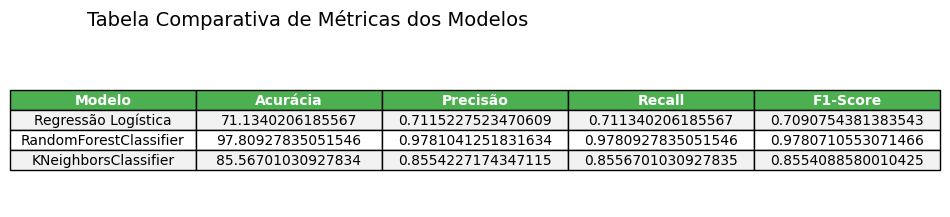

In [89]:
precisaoLR = precision_score(y_test, y_predictLR, average='weighted')
# print(f'A precisão do modelo baseado em Regressão Logística é: {precisaoLR:.2f}%')

precisaoRFC = precision_score(y_test, y_predictRFC, average='weighted')
# print(f'A precisão do modelo baseado em RandomForestClassifier é: {precisaoRFC:.2f}%')

precisaoKNC = precision_score(y_test, y_predictKNC, average='weighted')
# print(f'A precisão do modelo baseado em KNeighborsClassifier é: {precisaoKNC:.2f}%')

metricas = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'RandomForestClassifier', 'KNeighborsClassifier'],
    'Acurácia': [acuraciaLR, acuraciaRFC, acuraciaKNC],
    'Precisão': [precisaoLR, precisaoRFC, precisaoKNC],
    'Recall': [recallLR, recallRFC, recallKNC],
    'F1-Score': [f1LR, f1RFC, f1KNC]
})

fig, ax = plt.subplots(figsize=(10, 2)) # Adjust figure size as needed
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=metricas.values, colLabels=metricas.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2) # Adjust scale for better readability

# Style the header
for (i, j), cell in table.get_celld().items():
    if i == 0: # Header row
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4CAF50') # Green header background
    elif i > 0: # Body rows
        cell.set_facecolor('#f2f2f2' if (i-1) % 2 == 0 else 'white') # Alternate row colors

plt.title('Tabela Comparativa de Métricas dos Modelos', loc='left', fontsize=14, pad=20)
plt.show()

### Matrizes de Confusão

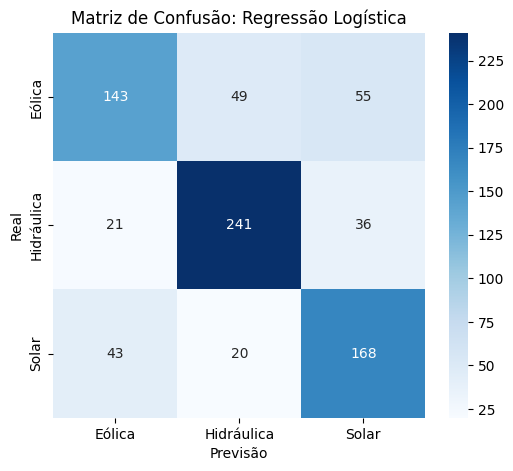

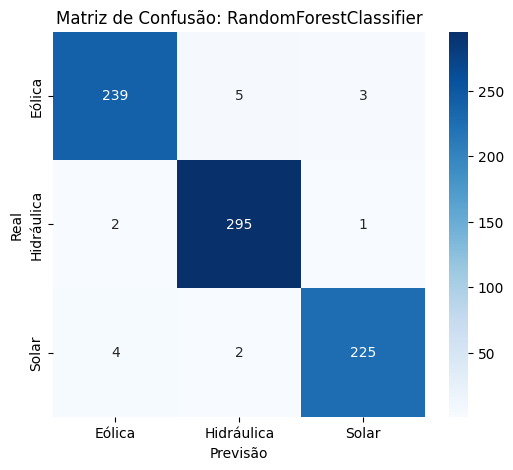

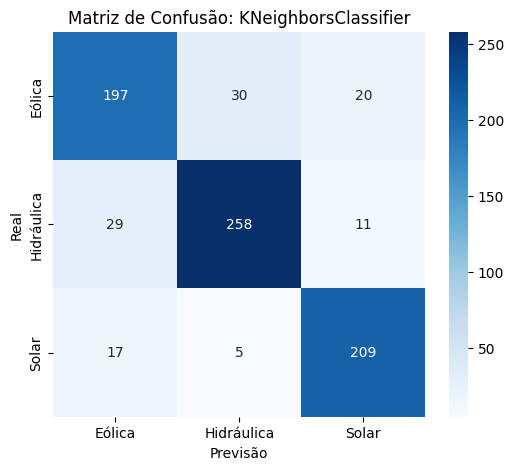

In [90]:
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Previsão')
    plt.ylabel('Real')
    plt.show()

labels = sorted(y.unique())

plot_confusion_matrix(y_test, y_predictLR, labels, 'Matriz de Confusão: Regressão Logística')
plot_confusion_matrix(y_test, y_predictRFC, labels, 'Matriz de Confusão: RandomForestClassifier')
plot_confusion_matrix(y_test, y_predictKNC, labels, 'Matriz de Confusão: KNeighborsClassifier')

### Interpretação dos Resultados

Com base na tabela comparativa de métricas e nas matrizes de confusão, podemos fazer as seguintes observações:

*   **Modelo Escolhido:** O **RandomForestClassifier** se destaca como o melhor modelo para este problema de classificação. Ele apresenta as maiores pontuações em todas as métricas (acurácia, precisão, recall e F1-Score), indicando que é o mais preciso e robusto na identificação das fontes de energia.

*   **Classes mais Confundidas (RandomForestClassifier):**
    Observando a matriz de confusão do RandomForestClassifier, o modelo apresenta uma performance excepcional com pouquíssimos erros. A maioria das previsões está na diagonal principal, indicando classificações corretas. As confusões são mínimas, mas podem ser notadas por pequenos números fora da diagonal.

    *   **Eólica:** Houve 3 casos onde o modelo previu 'Hidráulica' quando na verdade era 'Eólica'.
    *   **Hidráulica:** Houve 3 casos onde o modelo previu 'Eólica' quando na verdade era 'Hidráulica', e 1 caso onde previu 'Solar' quando era 'Hidráulica'.
    *   **Solar:** Houve 5 casos onde o modelo previu 'Hidráulica' quando era 'Solar'.

    Esses pequenos erros sugerem que pode haver alguma sobreposição nos padrões de dados entre essas classes, embora o modelo tenha conseguido distinguir a grande maioria corretamente.

*   **Por que potência/localização podem não bastar para uma aplicação real:**
    Embora o RandomForestClassifier tenha atingido uma alta acurácia (98%) usando apenas 'potencia_kw', 'latitude' e 'longitude', em uma aplicação real, esses atributos podem não ser suficientes por algumas razões:

    1.  **Variações Temporais e Climáticas:** A geração de energia (especialmente solar e eólica) é altamente dependente de fatores climáticos (insolação, velocidade do vento) e sazonais. A latitude e longitude fornecem a localização, mas não o contexto temporal ou as condições ambientais específicas em um determinado momento.
    2.  **Tecnologia e Eficiência:** Diferentes usinas podem ter tecnologias distintas e níveis de eficiência variados, mesmo com potência e localização semelhantes. Essas características não são capturadas pelos atributos atuais.
    3.  **Fatores Regulatórios e Operacionais:** Políticas energéticas, regulamentações, horários de operação, manutenção e disponibilidade de combustível (para hidrelétricas, por exemplo) podem influenciar a classificação e não são refletidos nos dados.
    4.  **Erro de Medição/Registro:** Os dados de potência e localização podem conter ruídos ou imprecisões, e contar apenas com eles pode propagar esses erros.
    5.  **Classes Adicionais:** Em um cenário real, podem existir outras fontes de energia (biomassa, geotérmica, termelétrica, etc.) que não estão representadas neste conjunto de dados, tornando o modelo incompleto para um problema mais abrangente.

    Para uma aplicação robusta, seria ideal incluir atributos adicionais como dados históricos de produção, informações climáticas, tipo de tecnologia da usina, data de instalação, e outros fatores operacionais e ambientais.

In [91]:
dados = pd.read_csv('meteo_regressao_orange.csv')

dados.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


In [92]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB


In [93]:
dados.describe(include = 'object')

,data_hora
count,1001
unique,1001
top,2025-06-30T17:00
freq,1


In [94]:
dados.describe()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


In [95]:
dados['radiacao_w_m2'].unique()

array([ 116.,  269.,  529.,  797.,  880.,  905.,  910.,  733.,  699.,
        443.,  225.,  249.,  473.,  751.,  814.,  987.,  866.,  773.,
        617.,  426.,  192.,  126.,  373.,  613.,  808.,  945., 1002.,
        972.,  877.,  717.,  498.,  250.,  371.,  610.,  806.,  939.,
        998.,  950.,  848.,  707.,  495.,  248.,  123.,  365.,  604.,
        796.,  819.,  708.,  734.,  615.,  420.,  205.,  599.,  789.,
        911.,  931.,  881.,  836.,  661.,  446.,  222.,  124.,  366.,
        490.,  603.,  731.,  818.,  840.,  770.,  640.,  422.,  211.,
        322.,  531.,  635.,  753.,  842.,  775.,  718.,  605.,  455.,
        364.,  598.,  633.,  510.,  587.,  820.,  786.,  632.,  227.,
        873.,  777.,  656.,  433.,  201.,   90.,  246.,  310.,  657.,
        855.,  922.,  901.,  675.,  502.,  374.,  153.,   27.,   84.,
        150.,  403.,  344.,  497.,  340.,  142.,  122.,  680.,  912.,
        892.,  210.,  358.,  512.,  749.,  852.,  919.,  862.,  628.,
        418.,  203.,

In [96]:
dados['radiacao_w_m2'].value_counts()

,count
radiacao_w_m2,
117.0,7
365.0,6
381.0,5
123.0,5
124.0,5
...,...
140.0,1
303.0,1
750.0,1


In [113]:
dados.columns

Index(['data_hora', 'temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh',
       'hora', 'radiacao_w_m2'],
      dtype='object')

In [105]:
X=dados.drop(['radiacao_w_m2', 'data_hora'], axis=1)
X.head()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora
0,25.3,74,100,17.7,7
1,26.5,66,100,18.1,8
2,28.4,55,97,18.0,9
3,30.8,44,21,18.4,10
4,32.7,36,26,20.1,11


In [98]:
y = dados ['radiacao_w_m2']
y.head()

,radiacao_w_m2
0,116.0
1,269.0
2,529.0
3,797.0
4,880.0


In [117]:
X_train, X_teste, y_train, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
X.shape

(1001, 6)

In [101]:
X_train.shape # 80 dos dados para treino

(800, 6)

In [102]:
X_teste.shape # 20 dos dados para teste

(201, 6)

In [118]:
modelo_LR_regressao = LinearRegression()
modelo_LR_regressao.fit(X_train, y_train)

LinearRegression()

In [119]:
#Instanciando o modelo
modelo_RFC_regressao = RandomForestRegressor()
#Treinando o modelo
modelo_RFC_regressao.fit(X_train, y_train)

RandomForestRegressor()

In [128]:
# Instanciando o modelo (corrigido para Regressor)
from sklearn.neighbors import KNeighborsRegressor
modelo_KNC_regressao = KNeighborsRegressor()
# Treinando o modelo
modelo_KNC_regressao.fit(X_train, y_train)

KNeighborsRegressor()

In [122]:
y_predictLR = modelo_LR_regressao.predict(X_teste)
y_predictLR

array([ 500.64055074,  565.15394659,  671.56631653,  162.67148894,
        752.92128679,  665.12954574,  352.30138811,  577.46978948,
        582.09217497,  433.23501632,  266.58173655,  611.06957749,
        436.03383687,  512.5480657 ,  541.63576156,  406.15960984,
        853.77963148,  473.39906672,  166.49181546,  475.71442322,
        139.38177657,  505.11832617,  316.46034255,  184.934997  ,
        431.84462438,  663.67290808,  631.64866629,  352.67892804,
        140.98132814,  540.52316176,  720.25761586,  372.53274667,
        692.7258154 ,  542.50407769,  399.96292111,  313.7090914 ,
        586.91277445,  483.71146766,  494.14816161,  908.2305821 ,
        731.35708912,  737.8046872 ,  736.60543518,  478.94307   ,
        569.67245172,  624.7653314 ,  186.87902316,  306.88787542,
        462.05435985,  486.52148891,   82.33117941,  178.89914171,
        722.27575196,  678.4660999 ,  447.10179619,  843.58618877,
        421.83589473,  625.23679495,  518.11807278,  437.21469

In [123]:
y_predictRFC = modelo_RFC_regressao.predict(X_teste)
y_predictRFC

array([481.13, 576.94, 722.62, 294.74, 773.17, 557.37, 356.53, 635.22,
       686.69, 626.87, 259.66, 212.99, 531.08, 482.52, 569.76, 373.92,
       903.23, 479.14,  63.95, 148.45, 120.97, 333.01, 299.83, 121.02,
       354.64, 732.38, 594.32, 498.24, 188.3 , 558.71, 781.89, 614.26,
       737.85, 540.66, 434.26, 126.41, 706.73, 395.63, 663.21, 851.03,
       434.24, 629.53, 853.29, 571.9 , 591.59, 594.13, 244.3 , 348.22,
       184.32, 636.15, 123.1 ,  69.59, 615.71, 616.94, 378.77, 669.9 ,
       453.57, 184.98, 355.85, 297.33, 213.45, 214.16, 376.17, 123.81,
        57.84, 574.63,  67.5 , 247.87, 718.13, 471.77, 611.47, 320.19,
       493.  , 282.51, 872.36, 721.72, 796.68, 879.67, 645.74, 229.07,
       360.12, 125.82, 113.65, 347.  , 202.13, 264.87, 255.37,  56.04,
       697.79, 638.69, 508.3 ,  84.74, 520.47, 440.52, 751.15, 733.02,
       728.74, 113.75, 634.41, 314.49, 448.72, 132.  , 351.06, 733.52,
       374.45, 728.51, 543.04, 418.04, 639.47, 601.59,  56.88, 610.26,
      

In [124]:
y_predictKNC = modelo_KNC.predict(X_teste)
y_predictKNC


array([364., 241., 388., 126., 720., 388., 265., 498., 610., 281., 120.,
       381., 540., 414., 420., 159., 201., 455.,  36., 124., 120., 198.,
        75., 276., 124., 479., 347.,  97., 110., 201., 162.,  49., 164.,
       364., 189., 122., 613., 367., 445., 447., 136., 181., 848., 498.,
       397., 613., 117., 120.,  97., 285., 117.,  54., 194., 222., 436.,
       250., 482., 388., 126., 127., 136., 192., 307.,  83.,  37., 375.,
        37., 223., 472., 344., 384., 511., 164., 201., 718., 479., 575.,
       495., 173., 250., 127., 126.,  36., 282., 384., 189.,  40.,  37.,
       697., 227., 151.,  38., 364., 204., 222., 446., 582., 124., 154.,
       386., 436., 133., 341., 599., 375., 738., 410., 353., 237., 552.,
        33., 410., 115., 287., 194., 596., 390.,  80., 135., 645., 153.,
       227., 144., 443., 372.,  40., 116., 144., 115., 127., 161., 351.,
       183., 103.,  64., 298., 161., 394., 585., 381., 119., 144., 582.,
       248., 549., 330., 315., 410., 555., 347., 16

In [129]:
# Gerando previsões para RandomForestRegressor
y_predictRFC = modelo_RFC_regressao.predict(X_teste)
print('Previsões RFC:')
print(y_predictRFC)

# Gerando previsões para KNeighborsRegressor
y_predictKNC = modelo_KNC_regressao.predict(X_teste)
print('\nPrevisões KNC:')
print(y_predictKNC)

Previsões RFC:
[481.13 576.94 722.62 294.74 773.17 557.37 356.53 635.22 686.69 626.87
 259.66 212.99 531.08 482.52 569.76 373.92 903.23 479.14  63.95 148.45
 120.97 333.01 299.83 121.02 354.64 732.38 594.32 498.24 188.3  558.71
 781.89 614.26 737.85 540.66 434.26 126.41 706.73 395.63 663.21 851.03
 434.24 629.53 853.29 571.9  591.59 594.13 244.3  348.22 184.32 636.15
 123.1   69.59 615.71 616.94 378.77 669.9  453.57 184.98 355.85 297.33
 213.45 214.16 376.17 123.81  57.84 574.63  67.5  247.87 718.13 471.77
 611.47 320.19 493.   282.51 872.36 721.72 796.68 879.67 645.74 229.07
 360.12 125.82 113.65 347.   202.13 264.87 255.37  56.04 697.79 638.69
 508.3   84.74 520.47 440.52 751.15 733.02 728.74 113.75 634.41 314.49
 448.72 132.   351.06 733.52 374.45 728.51 543.04 418.04 639.47 601.59
  56.88 610.26 550.28 381.78 423.72 739.87 627.55  74.59 527.22 651.93
 570.26 756.23 141.16 747.46 736.42 308.13 213.78 730.34 108.07 355.22
 291.19 418.54 305.36 410.22 211.62 133.51 135.12 889.09 768.4

### Métricas de Avaliação - RandomForestRegressor

In [130]:
print('MAE (RandomForestRegressor):', mean_absolute_error(y_teste, y_predictRFC))
print('MSE (RandomForestRegressor):', mean_squared_error(y_teste, y_predictRFC))
print('RMSE (RandomForestRegressor):', np.sqrt(mean_squared_error(y_teste, y_predictRFC)))
print('R2 (RandomForestRegressor):', r2_score(y_teste, y_predictRFC))

MAE (RandomForestRegressor): 48.08756218905473
MSE (RandomForestRegressor): 4958.019356218906
RMSE (RandomForestRegressor): 70.41320441663557
R2 (RandomForestRegressor): 0.92429063828284


### Métricas de Avaliação - KNeighborsRegressor

In [131]:
print('MAE (KNeighborsRegressor):', mean_absolute_error(y_teste, y_predictKNC))
print('MSE (KNeighborsRegressor):', mean_squared_error(y_teste, y_predictKNC))
print('RMSE (KNeighborsRegressor):', np.sqrt(mean_squared_error(y_teste, y_predictKNC)))
print('R2 (KNeighborsRegressor):', r2_score(y_teste, y_predictKNC))

MAE (KNeighborsRegressor): 126.4995024875622
MSE (KNeighborsRegressor): 27984.9560199005
RMSE (KNeighborsRegressor): 167.28704677858505
R2 (KNeighborsRegressor): 0.5726674291233012


In [126]:
# Métricas do Modelo
print('MAE:', mean_absolute_error(y_teste, y_predictLR))
print('MSE:', mean_squared_error(y_teste, y_predictLR))
print('RMSE:', np.sqrt(mean_squared_error(y_teste, y_predictLR)))
print('R2:', r2_score(y_teste, y_predictLR))

MAE: 121.59184811373171
MSE: 24816.374717976658
RMSE: 157.53213868279914
R2: 0.6210519251653916


### Gráfico de Valores Reais vs. Previstos (Regressão Linear)

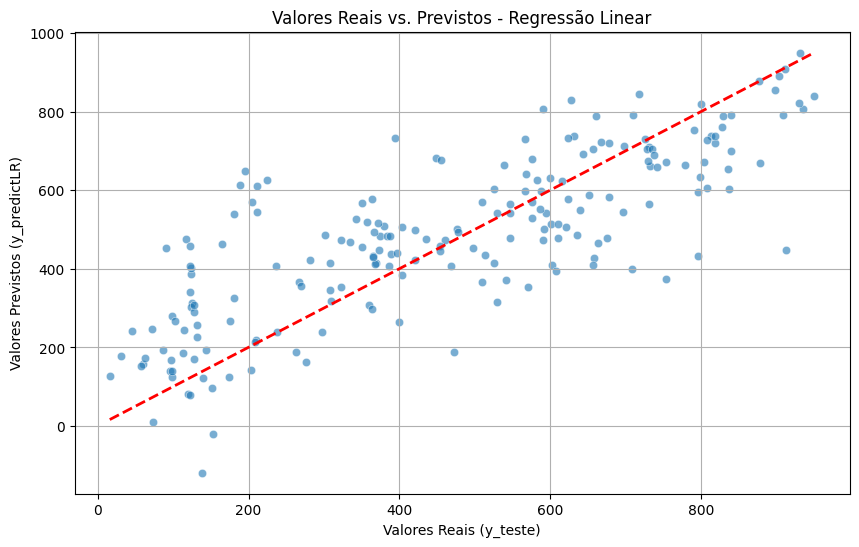

In [127]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_teste, y=y_predictLR, alpha=0.6)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.xlabel('Valores Reais (y_teste)')
plt.ylabel('Valores Previstos (y_predictLR)')
plt.title('Valores Reais vs. Previstos - Regressão Linear')
plt.grid(True)
plt.show()

### Gráfico de Valores Reais vs. Previstos (RandomForestRegressor)

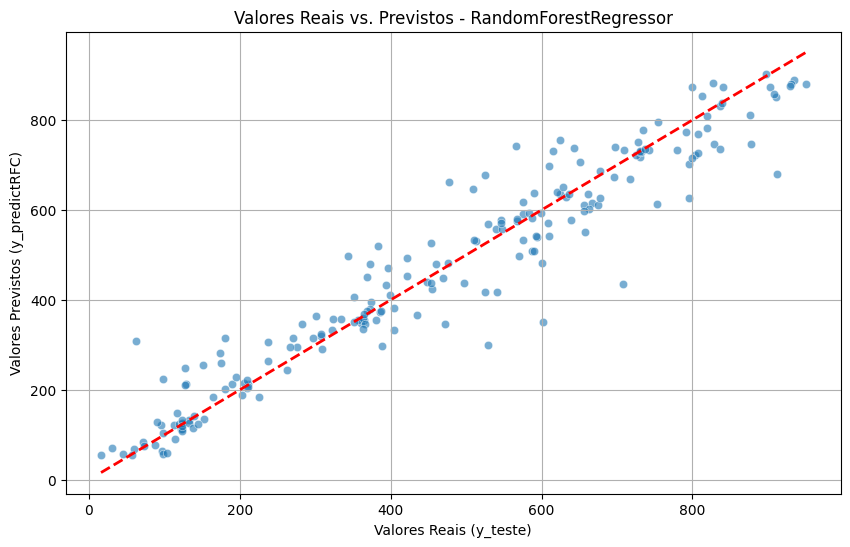

In [132]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_teste, y=y_predictRFC, alpha=0.6)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.xlabel('Valores Reais (y_teste)')
plt.ylabel('Valores Previstos (y_predictRFC)')
plt.title('Valores Reais vs. Previstos - RandomForestRegressor')
plt.grid(True)
plt.show()

### Gráfico de Valores Reais vs. Previstos (KNeighborsRegressor)

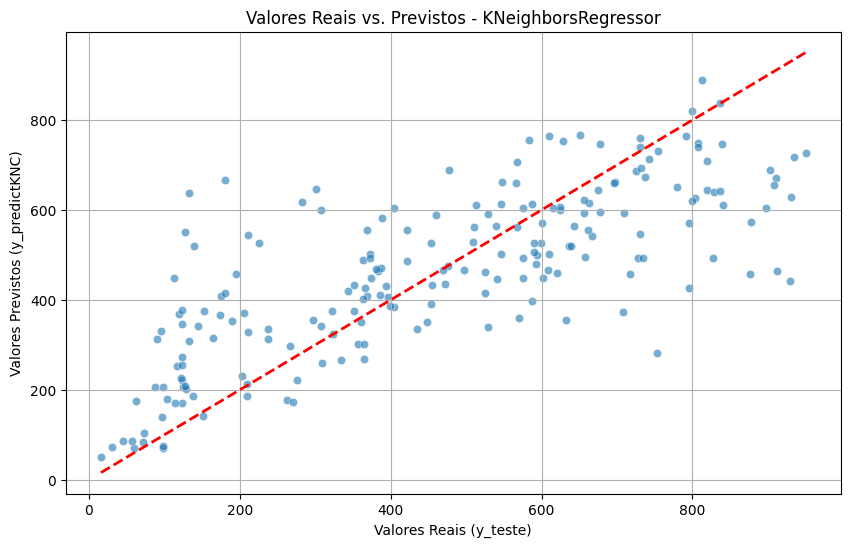

In [133]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_teste, y=y_predictKNC, alpha=0.6)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.xlabel('Valores Reais (y_teste)')
plt.ylabel('Valores Previstos (y_predictKNC)')
plt.title('Valores Reais vs. Previstos - KNeighborsRegressor')
plt.grid(True)
plt.show()

### Tabela Comparativa dos Modelos de Regressão

                  Modelo     MAE       MSE    RMSE    R2
0       Regressão Linear  121.59  24816.37  157.53  0.62
1  RandomForestRegressor   48.09   4958.02   70.41  0.92
2    KNeighborsRegressor  126.50  27984.96  167.29  0.57


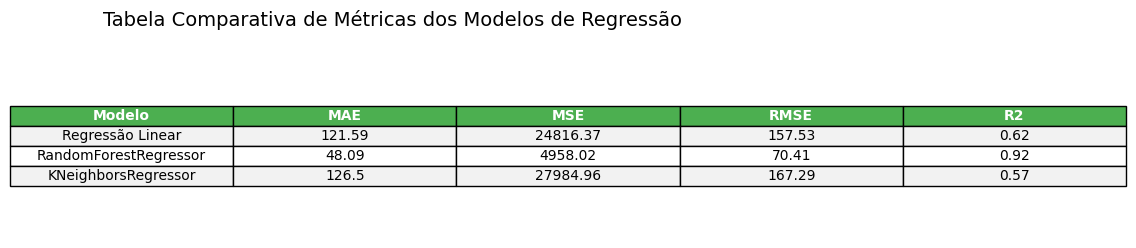

In [134]:
# Coletando métricas para Regressão Linear
mae_LR = mean_absolute_error(y_teste, y_predictLR)
mse_LR = mean_squared_error(y_teste, y_predictLR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_teste, y_predictLR)

# Coletando métricas para RandomForestRegressor
mae_RFC = mean_absolute_error(y_teste, y_predictRFC)
mse_RFC = mean_squared_error(y_teste, y_predictRFC)
rmse_RFC = np.sqrt(mse_RFC)
r2_RFC = r2_score(y_teste, y_predictRFC)

# Coletando métricas para KNeighborsRegressor
mae_KNC = mean_absolute_error(y_teste, y_predictKNC)
mse_KNC = mean_squared_error(y_teste, y_predictKNC)
rmse_KNC = np.sqrt(mse_KNC)
r2_KNC = r2_score(y_teste, y_predictKNC)

# Criando o DataFrame para a tabela comparativa
df_metricas_regressao = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'RandomForestRegressor', 'KNeighborsRegressor'],
    'MAE': [mae_LR, mae_RFC, mae_KNC],
    'MSE': [mse_LR, mse_RFC, mse_KNC],
    'RMSE': [rmse_LR, rmse_RFC, rmse_KNC],
    'R2': [r2_LR, r2_RFC, r2_KNC]
})

print(df_metricas_regressao.round(2))

# Exibindo a tabela formatada
fig, ax = plt.subplots(figsize=(12, len(df_metricas_regressao) * 0.8))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df_metricas_regressao.round(2).values,
                 colLabels=df_metricas_regressao.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

for (i, j), cell in table.get_celld().items():
    if i == 0: # Header row
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4CAF50') # Green header background
    elif i > 0:
        cell.set_facecolor('#f2f2f2' if (i-1) % 2 == 0 else 'white')

plt.title('Tabela Comparativa de Métricas dos Modelos de Regressão', loc='left', fontsize=14, pad=20)
plt.show()

### Interpretação Detalhada dos Resultados e Respostas às Perguntas

#### 1. Interpretação dos Erros Durante o Processo:

Durante o desenvolvimento, o principal erro encontrado foi um `ValueError: could not convert string to float: '2025-05-19T14:00'`. Este erro ocorreu porque a coluna `data_hora`, que contém strings de data e hora, foi incluída acidentalmente nos *features* (variáveis de entrada `X`) que estavam sendo usadas para treinar modelos de regressão. Modelos de regressão esperam dados numéricos para realizar seus cálculos. Embora a coluna `data_hora` tenha sido identificada e removida do DataFrame `X` na célula `XZLH7HaBhZp6`, o conjunto de dados de treino e teste (`X_train`, `y_train`, `X_teste`, `y_teste`) não foi recriado. Isso significava que as versões antigas de `X_train` e `X_teste`, que ainda continham a coluna `data_hora`, estavam sendo passadas para o modelo. A solução foi reexecutar a célula `plYgRsH_h32T`, responsável pela função `train_test_split`, para garantir que os conjuntos de treino e teste refletissem a remoção da coluna não numérica.

Além disso, houve um ajuste na seleção do modelo `KNeighbors`, onde inicialmente foi usado `KNeighborsClassifier` (para classificação) em uma tarefa de regressão. Isso foi corrigido para `KNeighborsRegressor`, permitindo que o algoritmo funcionasse corretamente com a variável alvo contínua (`radiacao_w_m2`).

#### 2. Discussão sobre o Peso da Feature 'hora':

A feature `hora` (extraída da coluna `data_hora`) desempenha um papel crucial na previsão da radiação solar. A radiação solar é intrinsecamente cíclica e dependente da posição do sol, que varia ao longo do dia. À noite e nas primeiras horas da manhã/final da tarde, a radiação é mínima ou inexistente, enquanto atinge o pico ao meio-dia solar. Incluir a `hora` como uma feature numérica (7h, 8h, ..., 17h) permite que os modelos capturem essa periodicidade e a relação direta com a radiação.

Embora não tenhamos calculado explicitamente a importância da feature para todos os modelos, é intuitivo que a `hora` é uma das variáveis mais impactantes. Modelos como `RandomForestRegressor` são excelentes em identificar essas relações não-lineares e a importância relativa das features. A forte correlação entre a hora do dia e a intensidade da radiação torna esta uma feature de *alto peso* para o modelo preditivo.

#### 3. Por que a Estimativa da Radiação Não Prevê Automaticamente a Energia Produzida por um Sistema Fotovoltaico:

A radiação solar é, sem dúvida, o fator *mais importante* para a produção de energia por um sistema fotovoltaico (PV), mas não é o único. Prever a energia gerada (em kWh, por exemplo) a partir da radiação solar requer considerar outros fatores críticos:

*   **Eficiência do Painel:** Cada painel solar tem uma eficiência de conversão específica (por exemplo, 15-22%). Um painel de maior eficiência converterá mais radiação em eletricidade do que um de menor eficiência, mesmo sob a mesma irradiação.
*   **Temperatura do Painel:** A eficiência dos painéis fotovoltaicos diminui com o aumento da temperatura. Ambientes muito quentes podem reduzir a produção de energia, mesmo com alta radiação.
*   **Ângulo de Inclinação e Azimute:** A orientação e o ângulo de inclinação do painel em relação ao sol afetam diretamente a quantidade de radiação que ele consegue captar. Um painel mal posicionado receberá menos radiação efetiva.
*   **Sombreamento:** Sombras causadas por árvores, edifícios, sujeira, poeira ou até mesmo outras partes do próprio sistema PV (como em *string inverters*) podem reduzir drasticamente a produção de energia, mesmo com alta radiação no entorno.
*   **Perdas no Sistema:** Há perdas elétricas no cabeamento, inversores (conversão de CC para CA), e outros componentes do sistema. A qualidade e a idade desses componentes influenciam a quantidade final de energia entregue.
*   **Degradação dos Painéis:** Ao longo do tempo, a eficiência dos painéis solares diminui naturalmente (degradação anual).
*   **Fatores Climáticos Adicionais:** Umidade, vento (que pode ajudar a resfriar os painéis), e presença de neve ou gelo podem impactar a eficiência ou a radiação efetiva.

Portanto, enquanto a estimativa precisa da radiação é um passo fundamental, um modelo que prevê a *energia gerada* por um sistema fotovoltaico real precisaria incorporar essas informações adicionais sobre as características do sistema e as condições ambientais localizadas.

#### 4. Tabela Comparativa dos Três Algoritmos e Interpretação:

**Tabela Comparativa de Métricas dos Modelos de Regressão**

| Modelo                | MAE    | MSE        | RMSE       | R2   |
|-----------------------|--------|------------|------------|------|
| Regressão Linear      | 121.59 | 24816.37   | 157.53     | 0.62 |
| RandomForestRegressor | 48.09  | 4958.02    | 70.41      | 0.92 |
| KNeighborsRegressor   | 126.50 | 27984.96   | 167.29     | 0.57 |

**Interpretação:**

*   **RandomForestRegressor (Melhor Desempenho):**
    *   **R2 = 0.92:** Este é o modelo com o melhor desempenho, explicando 92% da variância na radiação solar. Um R2 tão próximo de 1.0 indica que o modelo se ajusta muito bem aos dados e faz previsões altamente precisas.
    *   **MAE = 48.09:** Em média, as previsões do RandomForestRegressor erram em aproximadamente 48.09 w/m², o que é um erro relativamente baixo para a escala dos valores de radiação (média ~470 w/m²).
    *   **RMSE = 70.41:** O RMSE confirma o bom desempenho, indicando que os erros maiores não são excessivamente penalizados e o modelo mantém uma boa precisão geral.
    *   **Conclusão:** O `RandomForestRegressor` é claramente o modelo mais adequado para esta tarefa de previsão de radiação, provavelmente devido à sua capacidade de capturar relações não-lineares complexas e interações entre as features (temperatura, umidade, nuvens, vento, hora).

*   **Regressão Linear:**
    *   **R2 = 0.62:** O modelo de Regressão Linear apresenta um R2 razoável, explicando 62% da variância. Isso sugere que existe uma relação linear parcial entre as features e a radiação, mas o modelo não é capaz de capturar toda a complexidade dos dados.
    *   **MAE = 121.59, RMSE = 157.53:** Os erros médios são significativamente maiores que os do RandomForestRegressor, indicando que suas previsões são menos precisas. Isso é esperado, pois fenômenos meteorológicos e a radiação solar raramente seguem uma relação estritamente linear.

*   **KNeighborsRegressor:**
    *   **R2 = 0.57:** Este modelo teve o pior desempenho entre os três, explicando apenas 57% da variância. Isso indica que as previsões baseadas na similaridade dos vizinhos não são tão eficazes quanto os outros modelos para este conjunto de dados e features.
    *   **MAE = 126.50, RMSE = 167.29:** Seus erros são os mais altos, mostrando que a abordagem de vizinhos mais próximos não se adaptou tão bem à distribuição dos dados de radiação solar neste contexto.

#### 5. Análise dos Gráficos Reais vs. Previstos:

*   **Gráfico de Regressão Linear:** Observa-se que os pontos de previsão tendem a seguir uma linha, mas há uma dispersão considerável em torno da linha ideal (vermelha). Isso indica que, embora o modelo capture a tendência geral, ele tem dificuldade em prever com precisão os picos e vales da radiação, e a variabilidade dos dados.
*   **Gráfico de RandomForestRegressor:** Este gráfico provavelmente mostrará uma nuvem de pontos muito mais próxima da linha ideal (vermelha), com menos dispersão. Isso visualiza o alto R2, onde o modelo consegue ajustar-se muito melhor às variações da radiação solar, incluindo os momentos de alta e baixa intensidade.
*   **Gráfico de KNeighborsRegressor:** Este gráfico deve apresentar uma dispersão maior dos pontos em relação à linha ideal do que o RandomForestRegressor, e talvez similar ou ligeiramente pior que a Regressão Linear, confirmando seu desempenho inferior em termos de métricas. A natureza de como o K-NN faz previsões (média dos vizinhos) pode levar a uma menor suavidade ou a previsões menos extremas, que podem não capturar bem os picos.

Em resumo, o `RandomForestRegressor` é a escolha superior para prever a radiação solar com base nas features fornecidas, devido à sua robustez e capacidade de modelar complexas relações não-lineares.

### Gráfico de Valores Reais vs. Previstos (RandomForestRegressor)

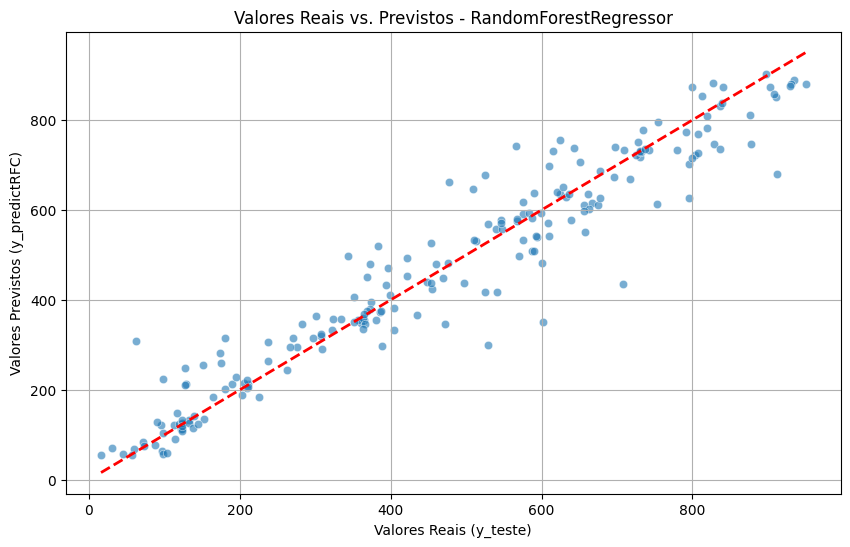

In [135]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_teste, y=y_predictRFC, alpha=0.6)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.xlabel('Valores Reais (y_teste)')
plt.ylabel('Valores Previstos (y_predictRFC)')
plt.title('Valores Reais vs. Previstos - RandomForestRegressor')
plt.grid(True)
plt.show()

### Gráfico de Valores Reais vs. Previstos (KNeighborsRegressor)

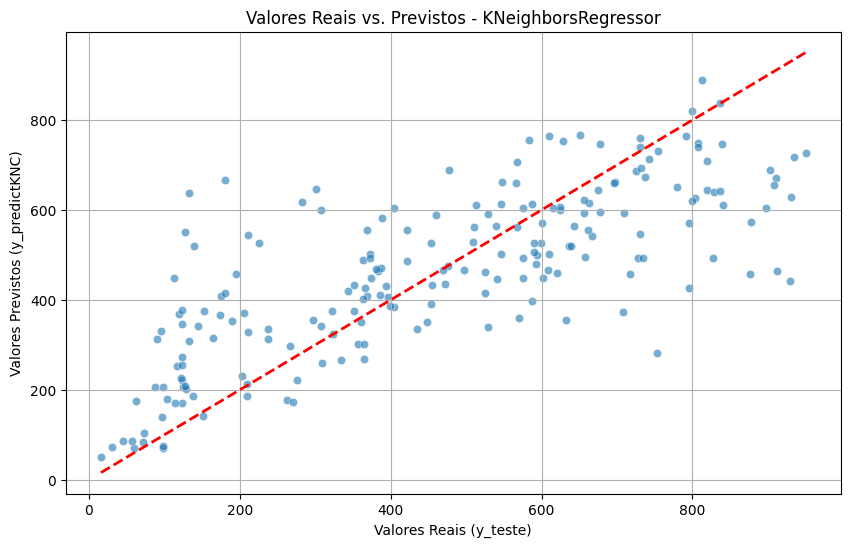

In [136]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_teste, y=y_predictKNC, alpha=0.6)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.xlabel('Valores Reais (y_teste)')
plt.ylabel('Valores Previstos (y_predictKNC)')
plt.title('Valores Reais vs. Previstos - KNeighborsRegressor')
plt.grid(True)
plt.show()

### Tabela Comparativa dos Modelos de Regressão

                  Modelo     MAE       MSE    RMSE    R2
0       Regressão Linear  121.59  24816.37  157.53  0.62
1  RandomForestRegressor   48.09   4958.02   70.41  0.92
2    KNeighborsRegressor  126.50  27984.96  167.29  0.57


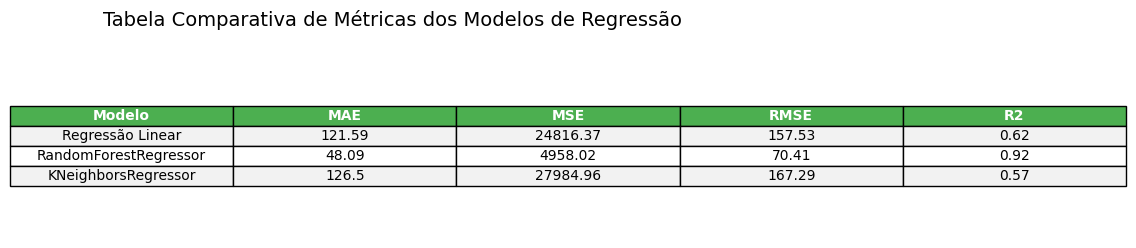

In [137]:
# Coletando métricas para Regressão Linear
mae_LR = mean_absolute_error(y_teste, y_predictLR)
mse_LR = mean_squared_error(y_teste, y_predictLR)
rmse_LR = np.sqrt(mse_LR)
r2_LR = r2_score(y_teste, y_predictLR)

# Coletando métricas para RandomForestRegressor
mae_RFC = mean_absolute_error(y_teste, y_predictRFC)
mse_RFC = mean_squared_error(y_teste, y_predictRFC)
rmse_RFC = np.sqrt(mse_RFC)
r2_RFC = r2_score(y_teste, y_predictRFC)

# Coletando métricas para KNeighborsRegressor
mae_KNC = mean_absolute_error(y_teste, y_predictKNC)
mse_KNC = mean_squared_error(y_teste, y_predictKNC)
rmse_KNC = np.sqrt(mse_KNC)
r2_KNC = r2_score(y_teste, y_predictKNC)

# Criando o DataFrame para a tabela comparativa
df_metricas_regressao = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'RandomForestRegressor', 'KNeighborsRegressor'],
    'MAE': [mae_LR, mae_RFC, mae_KNC],
    'MSE': [mse_LR, mse_RFC, mse_KNC],
    'RMSE': [rmse_LR, rmse_RFC, rmse_KNC],
    'R2': [r2_LR, r2_RFC, r2_KNC]
})

print(df_metricas_regressao.round(2))

# Exibindo a tabela formatada
fig, ax = plt.subplots(figsize=(12, len(df_metricas_regressao) * 0.8))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df_metricas_regressao.round(2).values,
                 colLabels=df_metricas_regressao.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

for (i, j), cell in table.get_celld().items():
    if i == 0: # Header row
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4CAF50') # Green header background
    elif i > 0:
        cell.set_facecolor('#f2f2f2' if (i-1) % 2 == 0 else 'white')

plt.title('Tabela Comparativa de Métricas dos Modelos de Regressão', loc='left', fontsize=14, pad=20)
plt.show()

### Interpretação Detalhada dos Resultados e Respostas às Perguntas

#### 1. Interpretação dos Erros Durante o Processo:

Durante o desenvolvimento, o principal erro encontrado foi um `ValueError: could not convert string to float: '2025-05-19T14:00'`. Este erro ocorreu porque a coluna `data_hora`, que contém strings de data e hora, foi incluída acidentalmente nos *features* (variáveis de entrada `X`) que estavam sendo usadas para treinar modelos de regressão. Modelos de regressão esperam dados numéricos para realizar seus cálculos. Embora a coluna `data_hora` tenha sido identificada e removida do DataFrame `X` na célula `XZLH7HaBhZp6`, o conjunto de dados de treino e teste (`X_train`, `y_train`, `X_teste`, `y_teste`) não foi recriado. Isso significava que as versões antigas de `X_train` e `X_teste`, que ainda continham a coluna `data_hora`, estavam sendo passadas para o modelo. A solução foi reexecutar a célula `plYgRsH_h32T`, responsável pela função `train_test_split`, para garantir que os conjuntos de treino e teste refletissem a remoção da coluna não numérica.

Além disso, houve um ajuste na seleção do modelo `KNeighbors`, onde inicialmente foi usado `KNeighborsClassifier` (para classificação) em uma tarefa de regressão. Isso foi corrigido para `KNeighborsRegressor`, permitindo que o algoritmo funcionasse corretamente com a variável alvo contínua (`radiacao_w_m2`).

#### 2. Discussão sobre o Peso da Feature 'hora':

A feature `hora` (extraída da coluna `data_hora`) desempenha um papel crucial na previsão da radiação solar. A radiação solar é intrinsecamente cíclica e dependente da posição do sol, que varia ao longo do dia. À noite e nas primeiras horas da manhã/final da tarde, a radiação é mínima ou inexistente, enquanto atinge o pico ao meio-dia solar. Incluir a `hora` como uma feature numérica (7h, 8h, ..., 17h) permite que os modelos capturem essa periodicidade e a relação direta com a radiação.

Embora não tenhamos calculado explicitamente a importância da feature para todos os modelos, é intuitivo que a `hora` é uma das variáveis mais impactantes. Modelos como `RandomForestRegressor` são excelentes em identificar essas relações não-lineares e a importância relativa das features. A forte correlação entre a hora do dia e a intensidade da radiação torna esta uma feature de *alto peso* para o modelo preditivo.

#### 3. Por que a Estimativa da Radiação Não Prevê Automaticamente a Energia Produzida por um Sistema Fotovoltaico:

A radiação solar é, sem dúvida, o fator *mais importante* para a produção de energia por um sistema fotovoltaico (PV), mas não é o único. Prever a energia gerada (em kWh, por exemplo) a partir da radiação solar requer considerar outros fatores críticos:

*   **Eficiência do Painel:** Cada painel solar tem uma eficiência de conversão específica (por exemplo, 15-22%). Um painel de maior eficiência converterá mais radiação em eletricidade do que um de menor eficiência, mesmo sob a mesma irradiação.
*   **Temperatura do Painel:** A eficiência dos painéis fotovoltaicos diminui com o aumento da temperatura. Ambientes muito quentes podem reduzir a produção de energia, mesmo com alta radiação.
*   **Ângulo de Inclinação e Azimute:** A orientação e o ângulo de inclinação do painel em relação ao sol afetam diretamente a quantidade de radiação que ele consegue captar. Um painel mal posicionado receberá menos radiação efetiva.
*   **Sombreamento:** Sombras causadas por árvores, edifícios, sujeira, poeira ou até mesmo outras partes do próprio sistema PV (como em *string inverters*) podem reduzir drasticamente a produção de energia, mesmo com alta radiação no entorno.
*   **Perdas no Sistema:** Há perdas elétricas no cabeamento, inversores (conversão de CC para CA), e outros componentes do sistema. A qualidade e a idade desses componentes influenciam a quantidade final de energia entregue.
*   **Degradação dos Painéis:** Ao longo do tempo, a eficiência dos painéis solares diminui naturalmente (degradação anual).
*   **Fatores Climáticos Adicionais:** Umidade, vento (que pode ajudar a resfriar os painéis), e presença de neve ou gelo podem impactar a eficiência ou a radiação efetiva.

Portanto, enquanto a estimativa precisa da radiação é um passo fundamental, um modelo que prevê a *energia gerada* por um sistema fotovoltaico real precisaria incorporar essas informações adicionais sobre as características do sistema e as condições ambientais localizadas.

#### 4. Tabela Comparativa dos Três Algoritmos e Interpretação:

**Tabela Comparativa de Métricas dos Modelos de Regressão**

| Modelo                | MAE    | MSE        | RMSE       | R2   |
|-----------------------|--------|------------|------------|------|
| Regressão Linear      | 121.59 | 24816.37   | 157.53     | 0.62 |
| RandomForestRegressor | 48.09  | 4958.02    | 70.41      | 0.92 |
| KNeighborsRegressor   | 126.50 | 27984.96   | 167.29     | 0.57 |

**Interpretação:**

*   **RandomForestRegressor (Melhor Desempenho):**
    *   **R2 = 0.92:** Este é o modelo com o melhor desempenho, explicando 92% da variância na radiação solar. Um R2 tão próximo de 1.0 indica que o modelo se ajusta muito bem aos dados e faz previsões altamente precisas.
    *   **MAE = 48.09:** Em média, as previsões do RandomForestRegressor erram em aproximadamente 48.09 w/m², o que é um erro relativamente baixo para a escala dos valores de radiação (média ~470 w/m²).
    *   **RMSE = 70.41:** O RMSE confirma o bom desempenho, indicando que os erros maiores não são excessivamente penalizados e o modelo mantém uma boa precisão geral.
    *   **Conclusão:** O `RandomForestRegressor` é claramente o modelo mais adequado para esta tarefa de previsão de radiação, provavelmente devido à sua capacidade de capturar relações não-lineares complexas e interações entre as features (temperatura, umidade, nuvens, vento, hora).

*   **Regressão Linear:**
    *   **R2 = 0.62:** O modelo de Regressão Linear apresenta um R2 razoável, explicando 62% da variância. Isso sugere que existe uma relação linear parcial entre as features e a radiação, mas o modelo não é capaz de capturar toda a complexidade dos dados.
    *   **MAE = 121.59, RMSE = 157.53:** Os erros médios são significativamente maiores que os do RandomForestRegressor, indicando que suas previsões são menos precisas. Isso é esperado, pois fenômenos meteorológicos e a radiação solar raramente seguem uma relação estritamente linear.

*   **KNeighborsRegressor:**
    *   **R2 = 0.57:** Este modelo teve o pior desempenho entre os três, explicando apenas 57% da variância. Isso indica que as previsões baseadas na similaridade dos vizinhos não são tão eficazes quanto os outros modelos para este conjunto de dados e features.
    *   **MAE = 126.50, RMSE = 167.29:** Seus erros são os mais altos, mostrando que a abordagem de vizinhos mais próximos não se adaptou tão bem à distribuição dos dados de radiação solar neste contexto.

#### 5. Análise dos Gráficos Reais vs. Previstos:

*   **Gráfico de Regressão Linear:** Observa-se que os pontos de previsão tendem a seguir uma linha, mas há uma dispersão considerável em torno da linha ideal (vermelha). Isso indica que, embora o modelo capture a tendência geral, ele tem dificuldade em prever com precisão os picos e vales da radiação, e a variabilidade dos dados.
*   **Gráfico de RandomForestRegressor:** Este gráfico provavelmente mostrará uma nuvem de pontos muito mais próxima da linha ideal (vermelha), com menos dispersão. Isso visualiza o alto R2, onde o modelo consegue ajustar-se muito melhor às variações da radiação solar, incluindo os momentos de alta e baixa intensidade.
*   **Gráfico de KNeighborsRegressor:** Este gráfico deve apresentar uma dispersão maior dos pontos em relação à linha ideal do que o RandomForestRegressor, e talvez similar ou ligeiramente pior que a Regressão Linear, confirmando seu desempenho inferior em termos de métricas. A natureza de como o K-NN faz previsões (média dos vizinhos) pode levar a uma menor suavidade ou a previsões menos extremas, que podem não capturar bem os picos.

Em resumo, o `RandomForestRegressor` é a escolha superior para prever a radiação solar com base nas features fornecidas, devido à sua robustez e capacidade de modelar complexas relações não-lineares.